# 1. Describe con detenimiento el problema de negocio que se desea resolver, y cómo se va a hacer esto. Indica la metodología, tareas a realizar, variable objetivo a predecir,etc.

El problema de negocio que se desea resolver es desarrollar un modelo predictivo que pueda estimar con precisión el precio de los boletos de avión. Esto es crucial para las agencias de viajes en línea que desean ofrecer a sus clientes estimaciones precisas del precio de los boletos de avión para sus próximos viajes. El precio de un boleto puede variar de manera significativa debido a diversos factores, como la compañía aérea, el destino, la temporada, la clase de servicio y la anticipación de la reserva. Esto dificulta que las empresas establezcan precios óptimos que maximicen sus ganancias y satisfagan a los clientes.

Para abordar este problema, se utilizará una metodología de Data Science que incluirá las siguientes tareas:

Comprensión del problema: Comprender completamente los requisitos del negocio y los objetivos del proyecto, así como también los datos disponibles y las limitaciones.

Exploración y preprocesamiento de datos: Explorar los datos disponibles para comprender su estructura y calidad. Esto incluirá la limpieza de datos, manejo de valores faltantes, codificación de variables categóricas, normalización de variables numéricas, etc.

Selección de características: Identificar las características más relevantes que puedan influir en el precio de los boletos de avión. Esto puede implicar el análisis de la importancia de las características y la eliminación de características irrelevantes o redundantes.

Entrenamiento de modelos: Experimentar con diferentes algoritmos de Machine Learning para entrenar modelos predictivos. Esto podría incluir regresión lineal, regresión lasso, árboles de decisión, etc.

Validación del modelo: Evaluar el rendimiento del modelo utilizando técnicas como la validación cruzada y métricas de evaluación como el error cuadrático medio (MSE), el error absoluto medio (MAE), el coeficiente de determinación (R cuadrado), etc.

Ajuste de hiperparámetros: Ajustar los hiperparámetros de los modelos para optimizar su rendimiento.

Despliegue del modelo: Implementar el modelo en un entorno de producción para que pueda ser utilizado por los clientes de la agencia de viajes en línea.

La variable objetivo a predecir será el precio del pasaje. Se utilizarán diversas características del vuelo, como la aerolínea, el destino, la temporada, la clase de servicio, la anticipación de la reserva, entre otras, como variables predictoras para el modelo.

En resumen, el objetivo es desarrollar un modelo de Machine Learning capaz de predecir el precio de los boletos de avión utilizando datos relevantes de vuelos, con el fin de proporcionar estimaciones precisas a los clientes de la agencia de viajes en línea

# 2. Carga los dataset entregados y genera un reporte de calidad de los mismos. Indica qué estrategias se van a utilizar para aquellos puntos encontrados (Indicar nulos, outliers, valores perdidos, que se hará con esto, etc.)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Carga del conjunto de datos 'business.xlsx'
business = pd.read_excel('/content/drive/MyDrive/EXCEL DESAFIOS/business.xlsx')

print(business.shape)
business.head()

(93487, 11)


,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price
0,2022-02-11,Air India,AI,868,18:00:00,Delhi,02h 00m,non-stop,20:00:00,Mumbai,25612
1,2022-02-11,Air India,AI,624,19:00:00,Delhi,02h 15m,non-stop,21:15:00,Mumbai,25612
2,2022-02-11,Air India,AI,531,20:00:00,Delhi,24h 45m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,20:45:00,Mumbai,42220
3,2022-02-11,Air India,AI,839,21:25:00,Delhi,26h 30m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55:00,Mumbai,44450
4,2022-02-11,Air India,AI,544,17:15:00,Delhi,06h 40m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55:00,Mumbai,46690


In [ ]:
# Carga del conjunto de datos 'economy.xlsx'
economy = pd.read_excel('/content/drive/MyDrive/EXCEL DESAFIOS/economy.xlsx')

print(economy.shape)
economy.head()

(206774, 11)


,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price
0,2022-02-11,SpiceJet,SG,8709,18:55:00,Delhi,02h 10m,non-stop,21:05:00,Mumbai,5953
1,2022-02-11,SpiceJet,SG,8157,06:20:00,Delhi,02h 20m,non-stop,08:40:00,Mumbai,5953
2,2022-02-11,AirAsia,I5,764,04:25:00,Delhi,02h 10m,non-stop,06:35:00,Mumbai,5956
3,2022-02-11,Vistara,UK,995,10:20:00,Delhi,02h 15m,non-stop,12:35:00,Mumbai,5955
4,2022-02-11,Vistara,UK,963,08:50:00,Delhi,02h 20m,non-stop,11:10:00,Mumbai,5955


In [ ]:
# Creamos variable 'class_type' en ambos dataframe.
valor_1 = 'business'
valor_2 = 'economy'

business['class_type'] = valor_1
economy['class_type'] = valor_2

In [ ]:
# Concatenamos ambos conjuntos de datos.
data_inicial = pd.concat([business, economy], ignore_index=True)

data_vuelos = data_inicial.copy()
print(data_vuelos.shape)
data_vuelos.head()

(300261, 12)


,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price,class_type
0,2022-02-11,Air India,AI,868,18:00:00,Delhi,02h 00m,non-stop,20:00:00,Mumbai,25612,business
1,2022-02-11,Air India,AI,624,19:00:00,Delhi,02h 15m,non-stop,21:15:00,Mumbai,25612,business
2,2022-02-11,Air India,AI,531,20:00:00,Delhi,24h 45m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,20:45:00,Mumbai,42220,business
3,2022-02-11,Air India,AI,839,21:25:00,Delhi,26h 30m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55:00,Mumbai,44450,business
4,2022-02-11,Air India,AI,544,17:15:00,Delhi,06h 40m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55:00,Mumbai,46690,business


In [ ]:
# Analizamos los datos.

def data_quality_analysis(df):
    # Crear un nuevo dataframe para almacenar los resultados
    result_df = pd.DataFrame(columns=['Columna', 'Tipo de dato', 'Valores únicos', 'Valores faltantes'])

    # Obtener información general del dataframe
    columns = df.columns
    data_types = df.dtypes.to_list()
    unique_values = [df[column].nunique() for column in columns]
    missing_values = [df[column].isnull().sum() for column in columns]

    # Llenar el nuevo dataframe con los resultados
    result_df['Columna'] = columns
    result_df['Tipo de dato'] = data_types
    result_df['Valores únicos'] = unique_values
    result_df['Valores faltantes'] = missing_values

    return result_df

# Ejemplo de uso de la función con el dataframe 'data_vuelos'
analysis_result = data_quality_analysis(data_vuelos).set_index('Columna')
analysis_result

,Tipo de dato,Valores únicos,Valores faltantes
Columna,,,
date,datetime64[ns],49,0
airline,object,8,0
ch_code,object,8,0
num_code,int64,1255,0
dep_time,object,251,0
from,object,6,0
time_taken,object,483,0
stop,object,40,0
arr_time,object,266,0


In [ ]:
# Eliminamos columnas variables que son innecesarias
variables_drop = ['ch_code', 'num_code']
data_vuelos = data_vuelos.drop(variables_drop, axis=1)

In [ ]:
# Transformamos variable 'dep_time' y 'arr_time'
data_vuelos['dep_time'] = data_vuelos['dep_time'].apply(lambda x: x.hour * 60 + x.minute)
data_vuelos['arr_time'] = data_vuelos['arr_time'].apply(lambda x: x.hour * 60 + x.minute)

In [ ]:
# Extraemos solo números y transformamos variable 'time_taken'
time_extract = data_vuelos['time_taken'].str.extract('(\d+)h (\d+)m', expand=True)
data_vuelos['time_taken'] = pd.to_numeric(time_extract[0], errors='coerce')*60 + pd.to_numeric(time_extract[1], errors='coerce')

In [ ]:
# Transformamos variable 'price'
data_vuelos['price'] = data_vuelos['price'].apply(lambda x: x.replace(',', '') if isinstance(x, str) else x)
data_vuelos['price'] = pd.to_numeric(data_vuelos['price'], errors='coerce')

In [ ]:
# Revisamos la variable con mayor rigurocidad
data_vuelos['stop'].value_counts()

stop
1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t\t\t\t\t\t\t                      243603
non-stop                                                                         36044
2+-stop                                                                          13288
1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia IXU\n\t\t\t\t\t\t\t\t\t\t\t\t                 1839
1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia IDR\n\t\t\t\t\t\t\t\t\t\t\t\t                 1398
1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia Patna\n\t\t\t\t\t\t\t\t\t\t\t\t                674
1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia Indore\n\t\t\t\t\t\t\t\t\t\t\t\t               381
1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia PAT\n\t\t\t\t\t\t\t\t\t\t\t\t                  354
1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia MYQ\n\t\t\t\t\t\t\t\t\t\t\t\t                  321
1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia Bhubaneswar\n\t\t\t\t\t\t\t\t\t\t\t\t          301
1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia KLH\n\t\t\t\t\t\t\t\t\t\t\t\t                  284
1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia JG

In [ ]:
# Realizaremos lo siguiente: 0 = 'non-stop', 1 = '1'-stop', 2 = '2'+-stop'
data_vuelos['stop'] = data_vuelos['stop'].str.replace('non-stop', '0stop')
data_vuelos['stop'] = data_vuelos['stop'].str.extract('(\d+)', expand = True).astype('float')

In [ ]:
# Ejemplo de uso de la función con el dataframe 'data_vuelos'
analysis_result = data_quality_analysis(data_vuelos).set_index('Columna')
analysis_result

,Tipo de dato,Valores únicos,Valores faltantes
Columna,,,
date,datetime64[ns],49,0
airline,object,8,0
dep_time,int64,251,0
from,object,6,0
time_taken,float64,476,4
stop,float64,3,0
arr_time,int64,266,0
to,object,6,0
price,int64,12165,0


In [ ]:
# Eliminamos datos faltantes.
data_vuelos = data_vuelos.dropna(axis = 0)

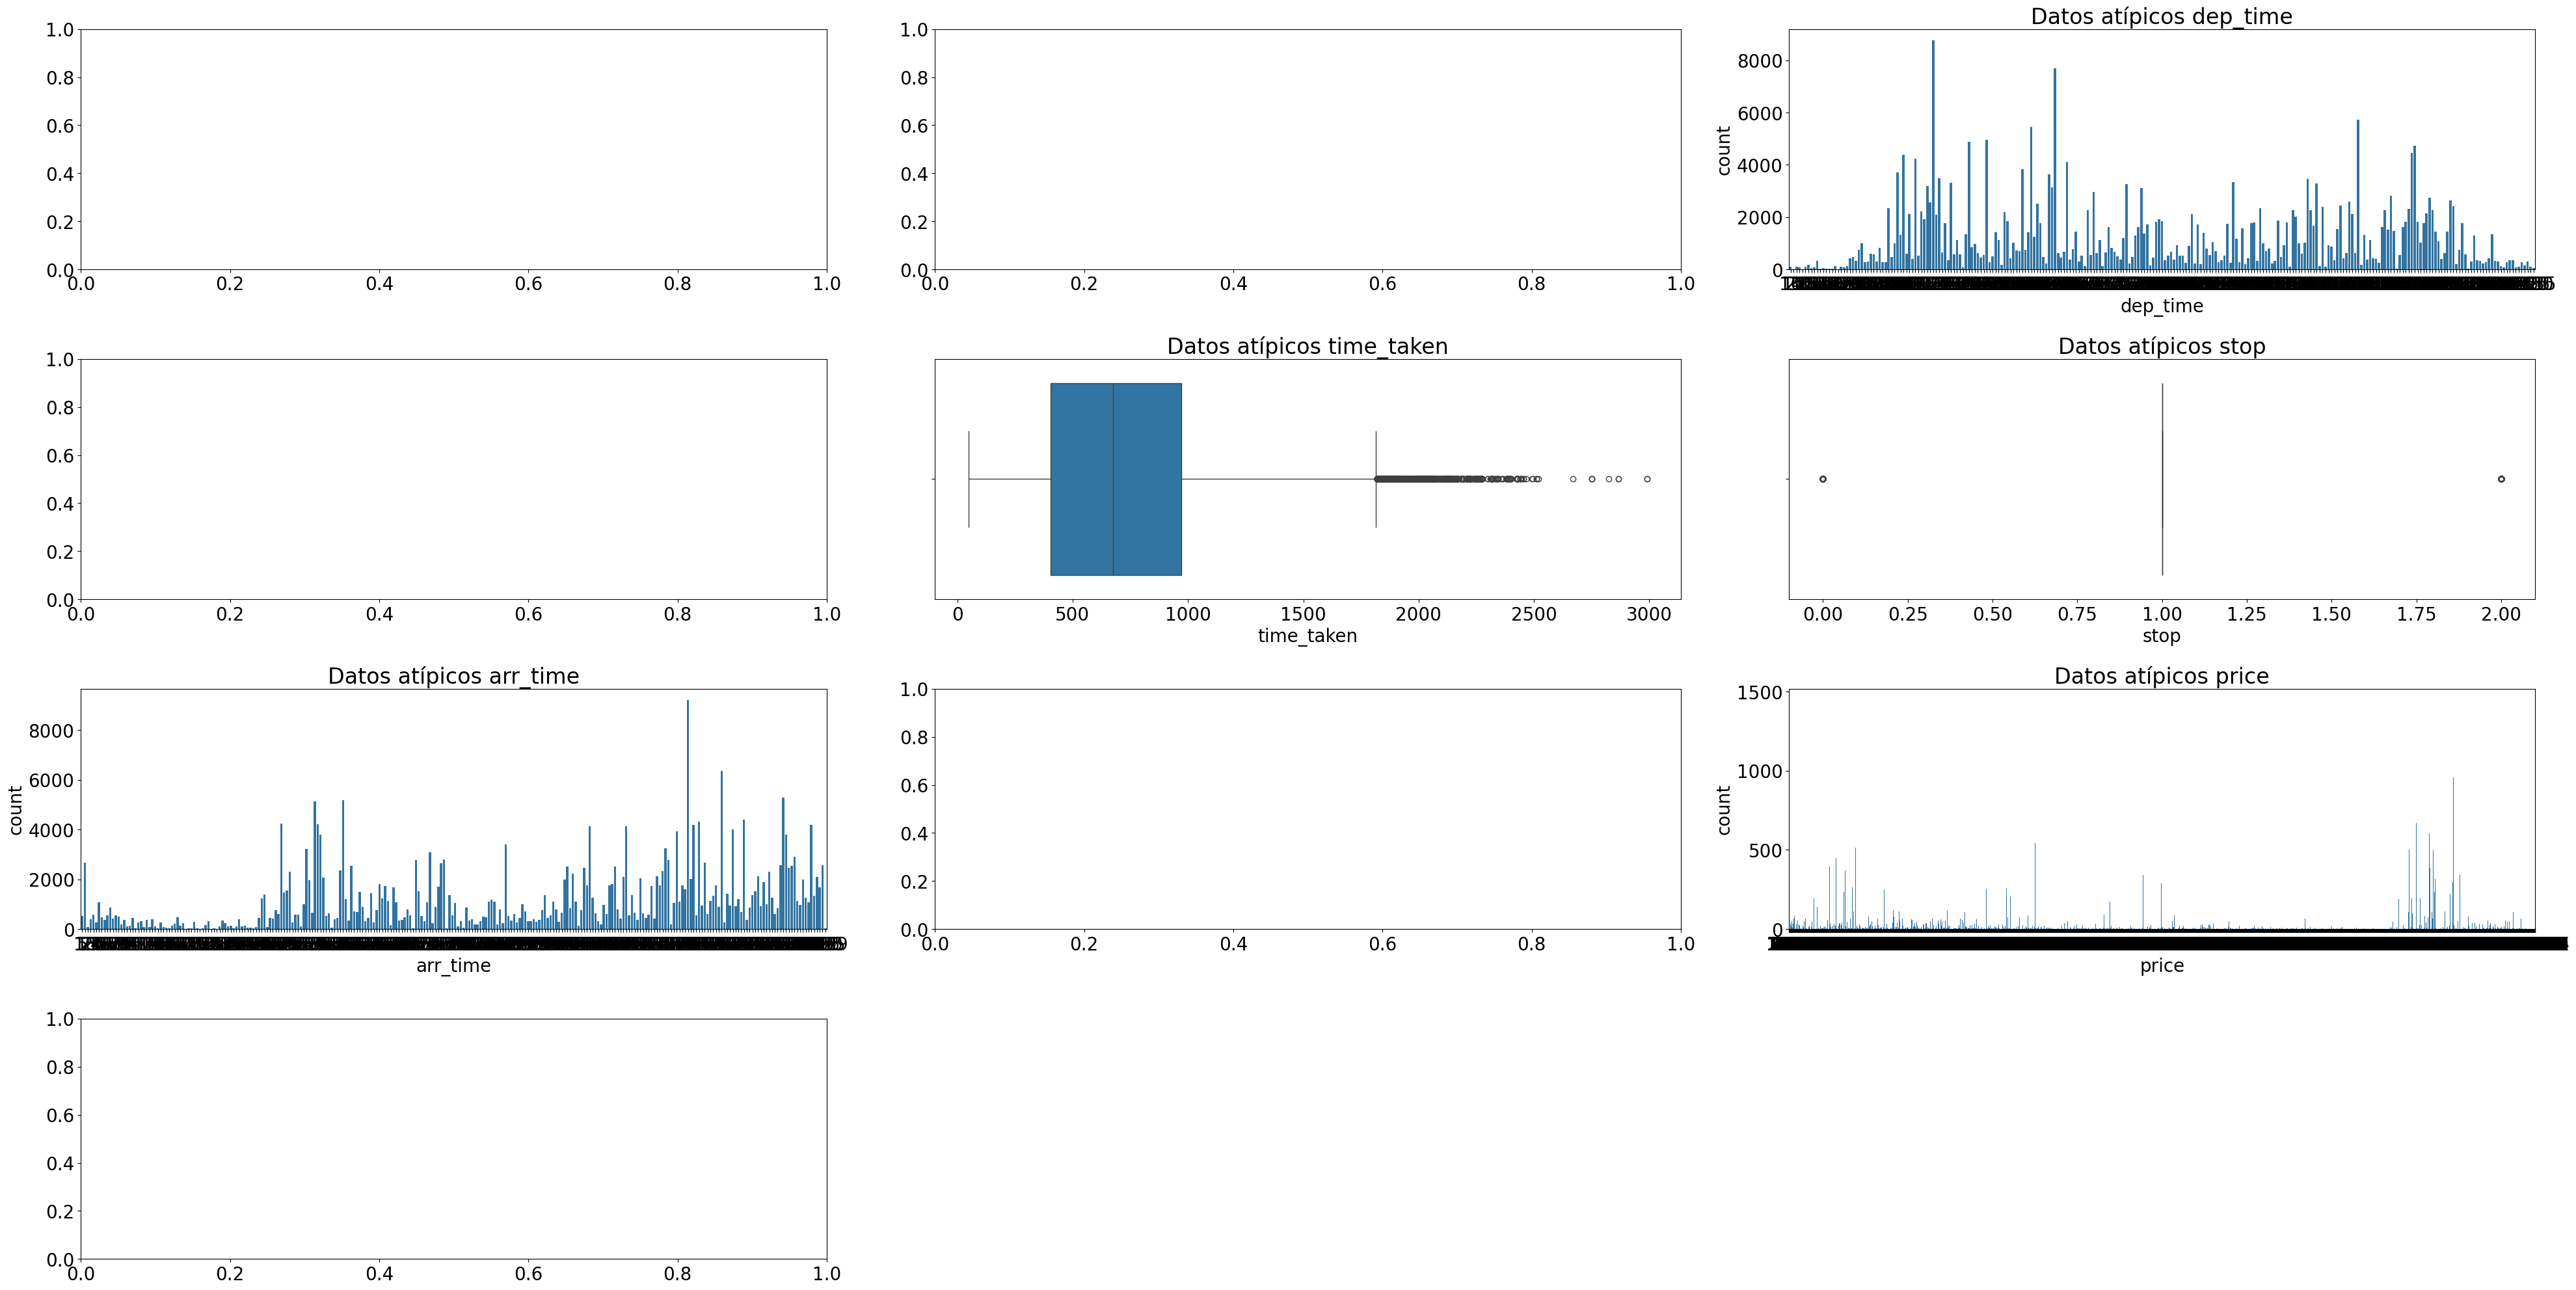

In [ ]:
plt.rcParams.update({'font.size': 20})

plt.figure(figsize=(40, 30))
for n, i in enumerate(list(data_vuelos.columns)):
    plt.subplot(6, 3, n + 1)
    if analysis_result.loc[i, 'Tipo de dato']=='int64':
        sns.countplot(x = data_vuelos[i])
        plt.title('Datos atípicos {}'.format(i))

    elif analysis_result.loc[i, 'Tipo de dato']=='float64':
        sns.boxplot(x = data_vuelos[i])
        plt.title('Datos atípicos {}'.format(i))

    plt.tight_layout()

In [ ]:
# Analisis descriptivo
data_vuelos.describe().round(2)

,date,dep_time,time_taken,stop,arr_time,price
count,300257,300257.00,300257.00,300257.00,300257.00,300257.00
mean,2022-03-08 00:06:38.250832128,806.04,733.07,0.92,943.82,20883.93
min,2022-02-11 00:00:00,10.00,50.00,0.00,5.00,1105.00
25%,2022-02-25 00:00:00,510.00,405.00,1.00,635.00,4783.00
50%,2022-03-08 00:00:00,775.00,675.00,1.00,1025.00,7425.00
75%,2022-03-20 00:00:00,1110.00,970.00,1.00,1245.00,42521.00
max,2022-03-31 00:00:00,1435.00,2990.00,2.00,1439.00,123071.00
std,NaN,323.36,431.57,0.40,363.09,22695.99


# 3. Genera un análisis exploratorio de los dataset entregados, un análisis univariado y bivariado. Prioriza los gráficos más importantes y entrega una conclusión a partir de estos.

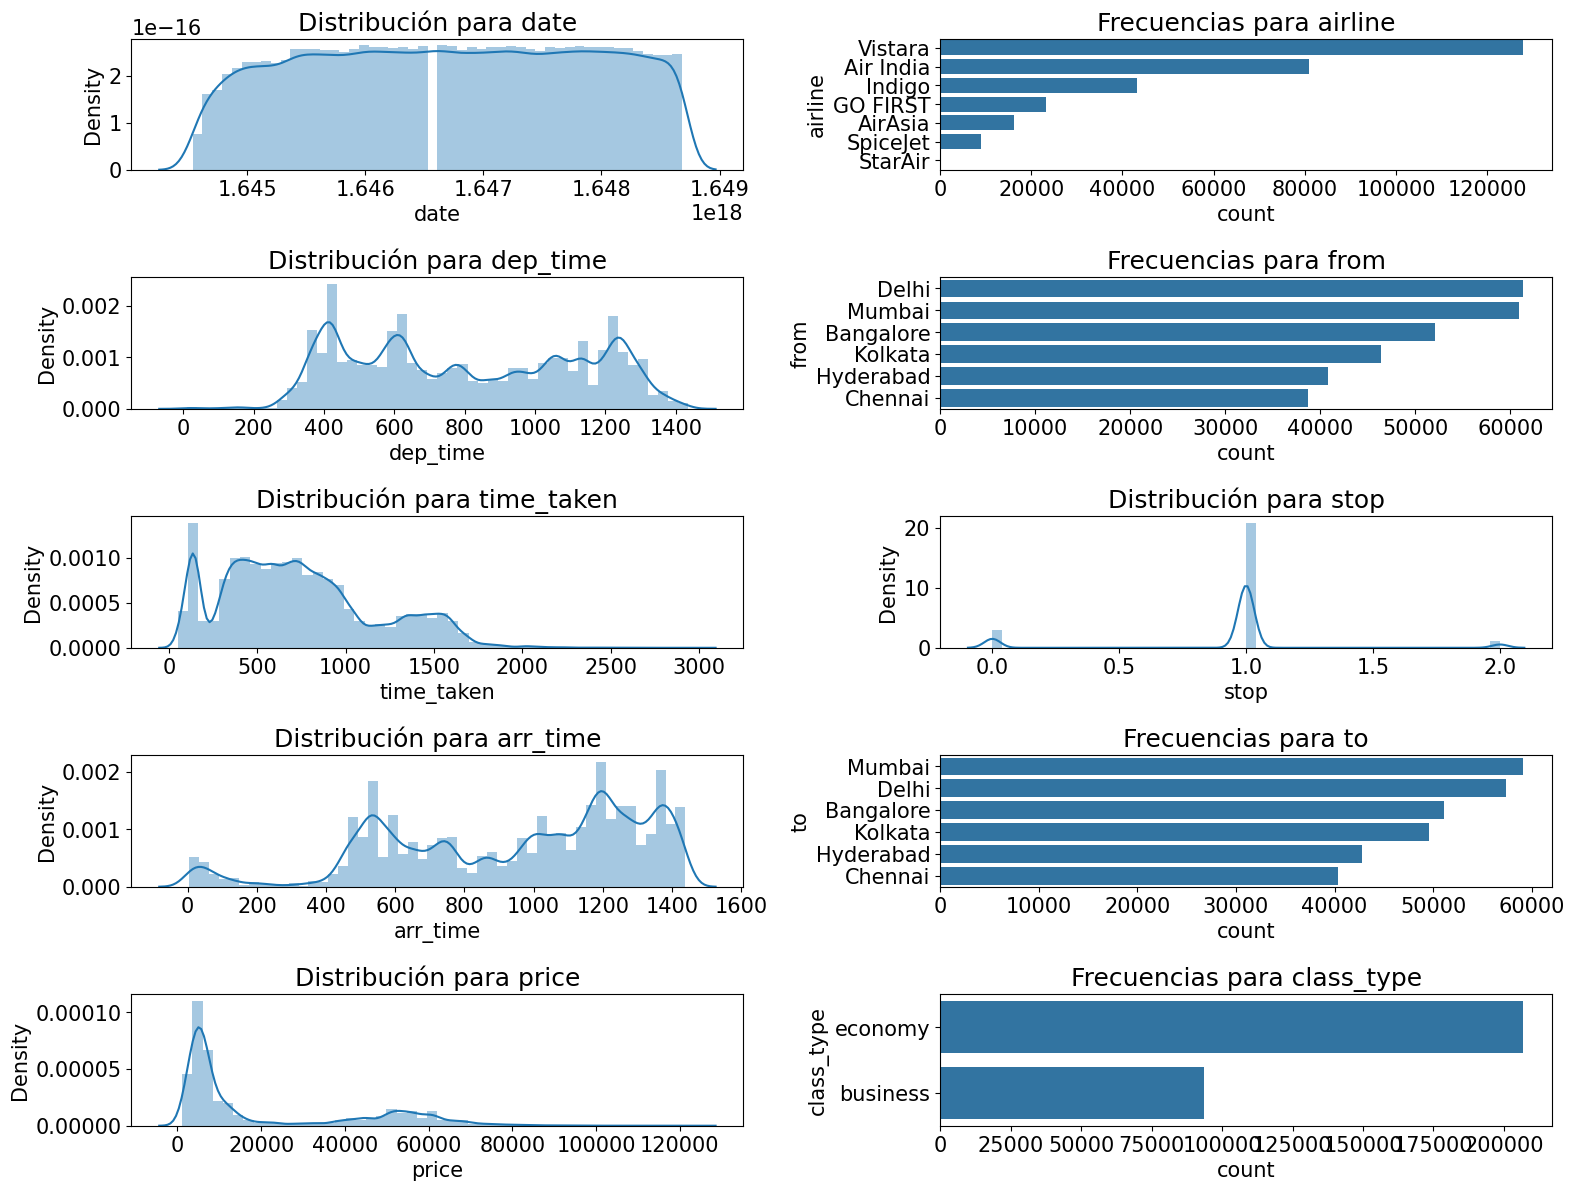

In [ ]:
# Gráficamos distribución de los datos
plt.rcParams.update({'font.size': 15})

plt.figure(figsize=(16, 14))
for n, i in enumerate(list(data_vuelos.columns)):
    plt.subplot(6, 2, n + 1)
    if analysis_result.loc[i, 'Tipo de dato']=='object':
        sns.countplot(y= data_vuelos[i], order=data_vuelos[i].value_counts().iloc[:7].index)
        plt.title('Frecuencias para {}'.format(i))

    else:
        sns.distplot(data_vuelos[i])
        plt.title('Distribución para {}'.format(i))
    plt.tight_layout()

In [ ]:
data_vuelos.describe().round(2)

,date,dep_time,time_taken,stop,arr_time,price
count,300257,300257.00,300257.00,300257.00,300257.00,300257.00
mean,2022-03-08 00:06:38.250832128,806.04,733.07,0.92,943.82,20883.93
min,2022-02-11 00:00:00,10.00,50.00,0.00,5.00,1105.00
25%,2022-02-25 00:00:00,510.00,405.00,1.00,635.00,4783.00
50%,2022-03-08 00:00:00,775.00,675.00,1.00,1025.00,7425.00
75%,2022-03-20 00:00:00,1110.00,970.00,1.00,1245.00,42521.00
max,2022-03-31 00:00:00,1435.00,2990.00,2.00,1439.00,123071.00
std,NaN,323.36,431.57,0.40,363.09,22695.99


In [ ]:
# Importamos librerías requeridas
import scipy.stats as stats

El test de ANOVA es significativo, al menos un grupo es diferente.


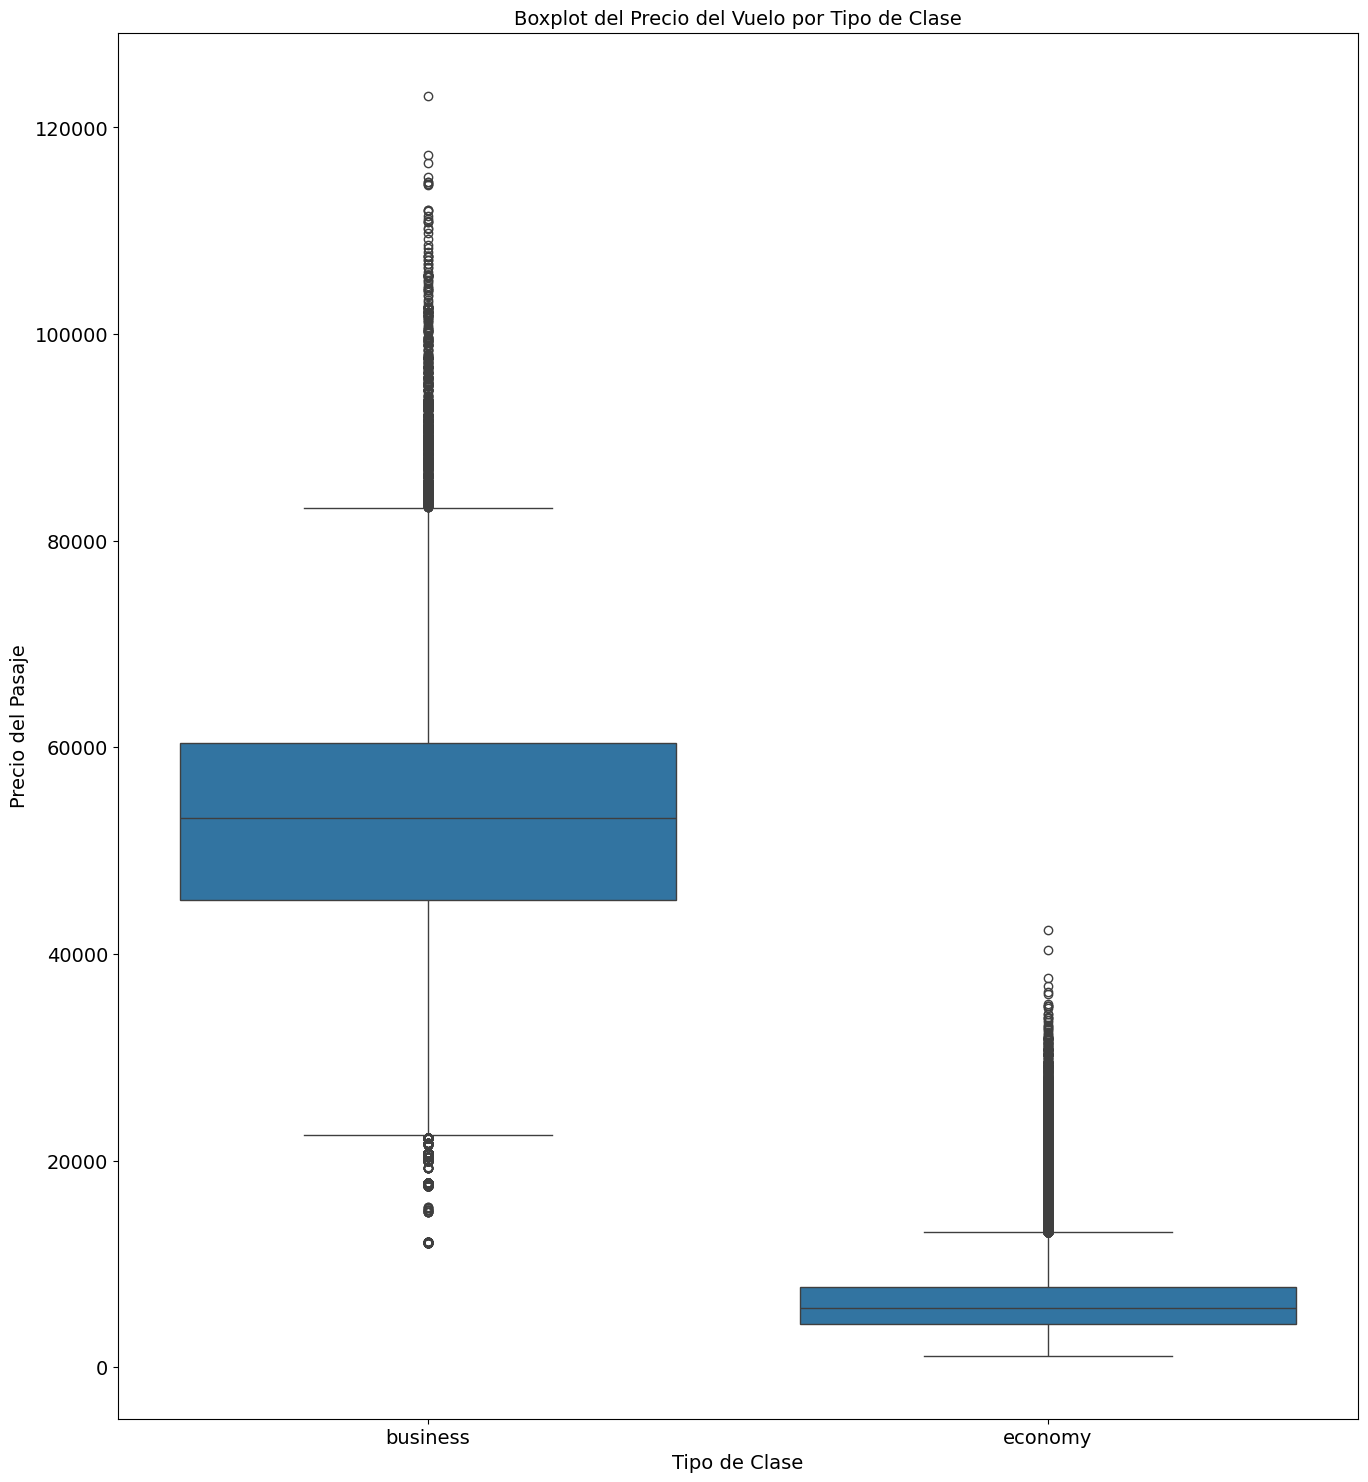

In [ ]:
# Agrupar los datos por tipo de clase.
grouped_data = [data_vuelos['price'][data_vuelos['class_type'] == class_type] for class_type in data_vuelos['class_type'].unique()]

# Realizar el test de ANOVA
statistic, p_value = stats.f_oneway(*grouped_data)

# Imprimir el resultado del test
alpha = 0.05
if p_value < alpha:
    print(f'\033[1mEl test de ANOVA es significativo, al menos un grupo es diferente.\033[1m')
else:
    print(f'\033[1mNo hay evidencia suficiente para rechazar la hipótesis nula.\033[1m')

# Graficar los datos con un boxplot
plt.rcParams.update({'font.size': 14})
plt.figure(figsize=(16, 18))
sns.boxplot(x='class_type', y='price', data=data_vuelos)
plt.xlabel('Tipo de Clase')
plt.ylabel('Precio del Pasaje')
plt.title('Boxplot del Precio del Vuelo por Tipo de Clase', fontsize=14)
plt.show()


**Observaciones del Diagrama de Cajas:**

**Precios Medianos:**
El precio mediano para la Clase Business es significativamente más alto que el precio mediano para la Clase Economy. Esto indica que, en general, los boletos de Clase Business son más costosos que los de Clase Economy.

**Distribución de Precios:**
El diagrama para la Clase Business muestra un rango de precios más amplio en comparación con la Clase Economy. Esto sugiere que hay más variabilidad en el precio de los boletos de Clase Business.
Los bigotes de la Clase Business se extienden más allá de los de la Clase Economy, lo que indica que hay algunos valores atípicos con precios excepcionalmente altos en la Clase Business.

**Sesgo:**
Ambas distribuciones de precios, Clase Business y Clase Economy, parecen estar ligeramente sesgadas hacia la derecha. Esto significa que hay algunos vuelos más caros que vuelos baratos.
Interpretación General:

El diagrama de cajas muestra claramente la diferencia en el precio de los boletos entre la Clase Business y la Clase Economy. Los boletos de Clase Business generalmente son más caros, pero también hay más variabilidad en su precio. Los boletos de Clase Economy tienen un rango de precios más estrecho y, en general, son más asequibles.

**Consideraciones Adicionales:**
El rango específico de precios para cada tipo de clase puede variar según la aerolínea, la ruta y otros factores.
El diagrama de cajas solo muestra la distribución de los precios de los boletos y no considera otros factores que pueden influir en la elección de clase de los pasajeros, como la comodidad, las comodidades y el tiempo de viaje.

El test de ANOVA es significativo, al menos un grupo es diferente.


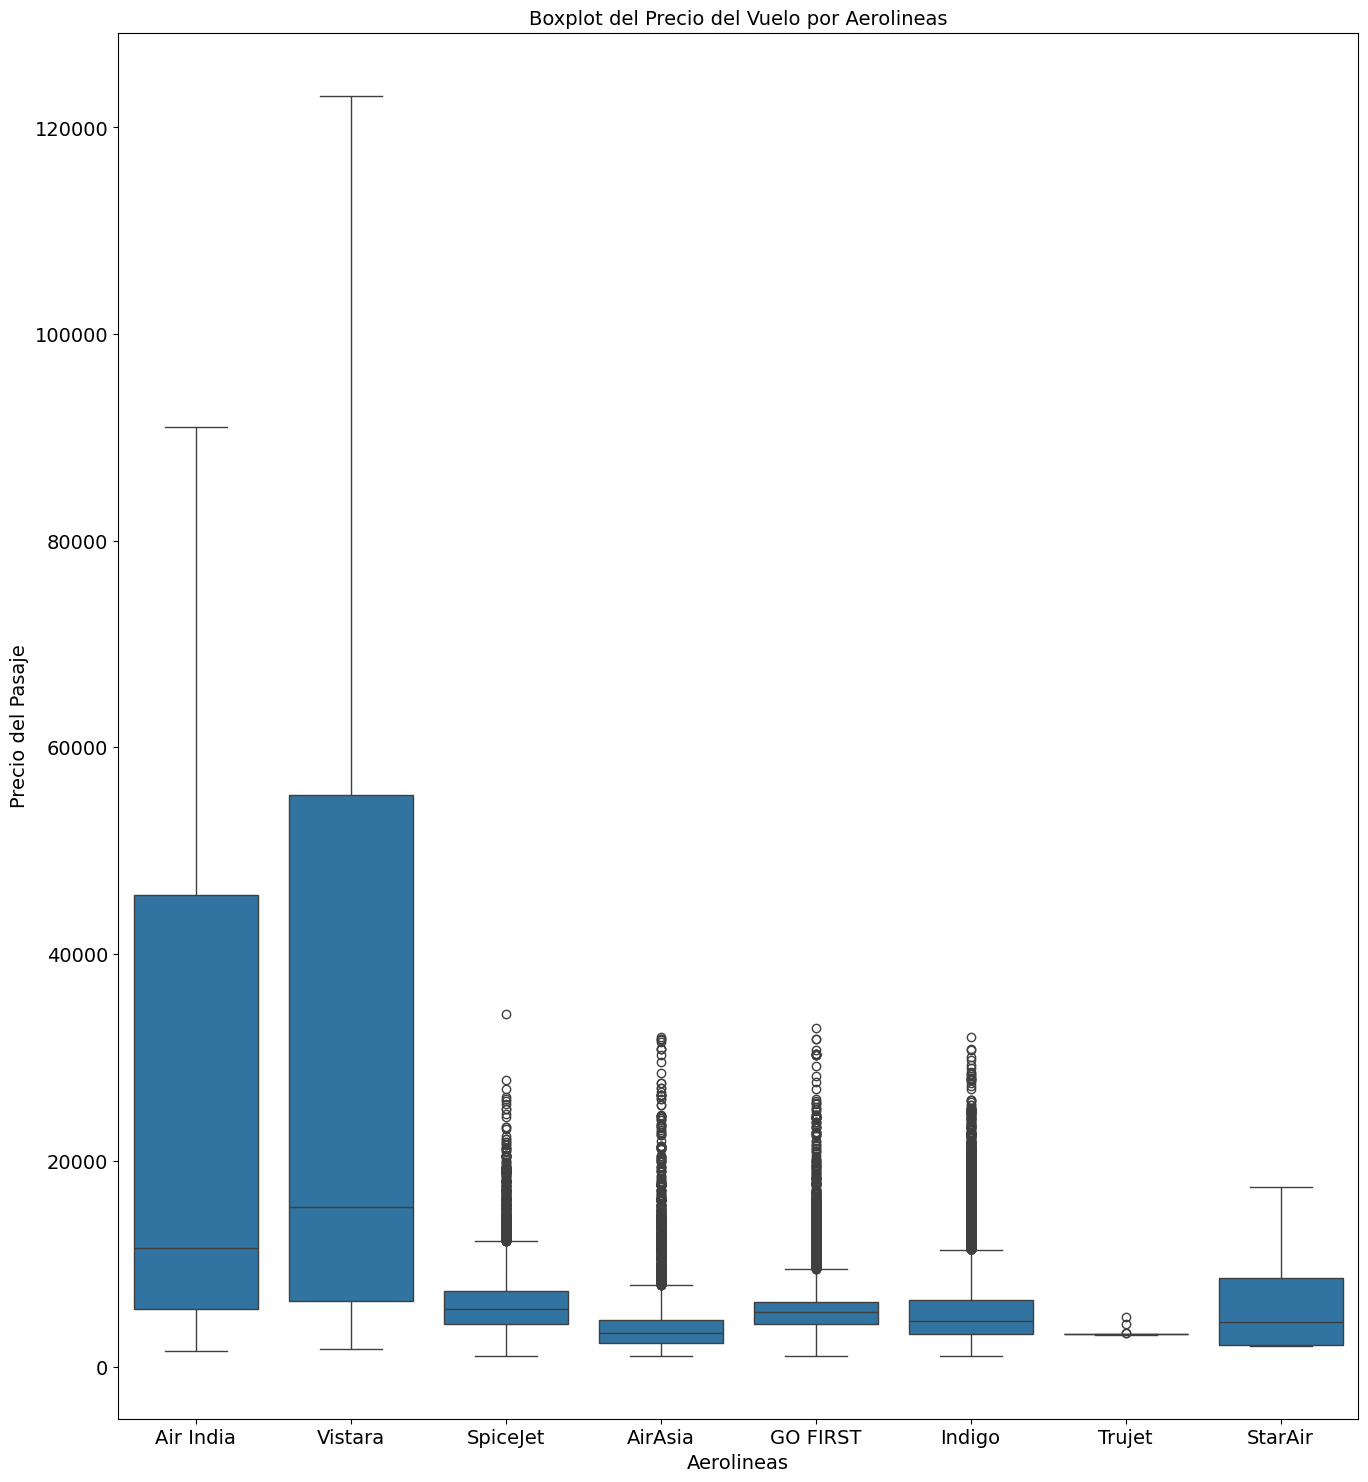

In [ ]:
# Agrupar los datos por aerolineas.
grouped_data = [data_vuelos['price'][data_vuelos['airline'] == airline] for airline in data_vuelos['airline'].unique()]

# Realizar el test de ANOVA
statistic, p_value = stats.f_oneway(*grouped_data)

# Imprimir el resultado del test
alpha = 0.05
if p_value < alpha:
    print(f'\033[1mEl test de ANOVA es significativo, al menos un grupo es diferente.\033[1m')
else:
    print(f'\033[1mNo hay evidencia suficiente para rechazar la hipótesis nula.\033[1m')

# Graficar los datos con un boxplot
plt.rcParams.update({'font.size': 14})
plt.figure(figsize=(16, 18))
sns.boxplot(x='airline', y='price', data=data_vuelos)
plt.xlabel('Aerolineas')
plt.ylabel('Precio del Pasaje')
plt.title('Boxplot del Precio del Vuelo por Aerolineas', fontsize=14)
plt.show()

**Observaciones del Diagrama de Cajas:**

**Precios Medianos:**
Los precios medios varían significativamente entre las distintas aerolíneas. Esto indica que existen diferencias considerables en el precio promedio de los vuelos ofrecidos por las distintas compañías aéreas.

**Distribución de Precios:**
Los diagramas de algunas aerolíneas, como AirAsia y Trujet, muestran un rango de precios más estrecho en comparación con otras, como Air India y Vistara. Esto sugiere que algunas aerolíneas tienen precios más uniformes, mientras que otras tienen un rango más amplio de precios para sus vuelos.
Los bigotes para algunas aerolíneas, como Air India y Vistara, se extienden más allá de los de otras, lo que indica que hay algunos valores atípicos con precios excepcionalmente altos o bajos en esas aerolíneas.

**Variabilidad General:**
Existe una gran variabilidad general en el precio promedio de los vuelos entre las distintas aerolíneas. Esto significa que los pasajeros pueden encontrar ahorros significativos al elegir una aerolínea con precios promedio más bajos.

**Interpretación General:**
El diagrama de cajas muestra claramente la amplia gama de precios promedio de vuelos que ofrecen las distintas aerolíneas. Los pasajeros pueden usar esta información para comparar precios y encontrar la opción más económica para sus necesidades de viaje.

**Consideraciones Adicionales:**
El rango específico de precios para cada aerolínea puede variar según la ruta, las fechas de viaje y otros factores.
El diagrama de cajas solo muestra la distribución de los precios promedio y no considera otros factores que pueden influir en la elección de aerolínea de los pasajeros, como la reputación, el horario y las comodidades.
Los pasajeros también pueden tener en cuenta sus programas de fidelidad y otros beneficios al elegir aerolínea.

**Recomendaciones para Análisis Posteriores:**
Para obtener una comprensión más detallada de los patrones de precios, se podría analizar la distribución de precios de cada aerolínea por separado.
Para explorar el impacto de otros factores en los precios de los boletos, se podrían realizar análisis adicionales, como considerar la ruta, las fechas de viaje o el momento de la reserva.
Para brindar recomendaciones más personalizadas a los viajeros, se podría tener en cuenta las preferencias individuales, las limitaciones presupuestarias y los objetivos del viaje.

# 4. Realiza un análisis de correlaciones entre las diferentes variables existentes, identificando cuáles son las variables más importantes para la predicción de la variable objetivo. Utiliza las técnicas vistas en el curso.

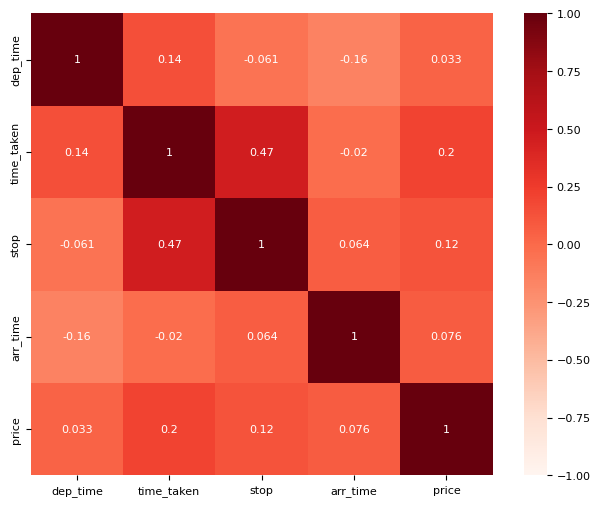

In [ ]:
# Graficamos la correlación entre las variables de la data.
correlacion = data_vuelos.select_dtypes(include = ['float64','int']).corr(method = 'pearson')

# Generamos una matriz de correlaciones
plt.rcParams.update({'font.size': 8})
plt.figure(figsize = (8,6))
sns.heatmap(correlacion,vmin = -1,vmax = 1,square = True,annot=True,cmap = 'Reds')
plt.show()

El mapa de calor de correlación revela varias relaciones interesantes entre las variables. La fuerte correlación positiva entre "dep_time" y "time_taken" sugiere que la hora de salida puede influir en la duración de la tarea. La fuerte correlación negativa entre "stop" y "time_taken" indica que el número de paradas tiene un impacto significativo en la duración de la tarea. Las correlaciones positivas moderadas entre "arr_time" y "time_taken" y "price" y "time_taken" implican que la hora de llegada y el precio de la tarea también pueden influir en la duración de la tarea. La correlación negativa moderada entre "time_taken" y "dep_time" sugiere que la hora de salida puede tener un efecto secundario en la duración de la tarea.

<Axes: >

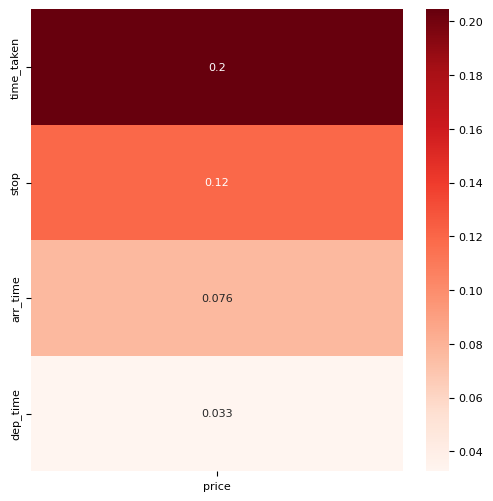

In [ ]:
#MAPA DE CORRELACION DE LA VARIABLE 'price'

# Graficamos de manera descendente desde la correlación mas alta hasta la mas baja.
correlacion = data_vuelos.select_dtypes(include = ['float64','int']).corr(method = 'pearson')

plt.rcParams.update({'font.size': 8})
plt.figure(figsize=(6, 6))

sns.heatmap(correlacion.loc[:, ['price']].sort_values('price', ascending=False).iloc[1:], annot=True, annot_kws={'size':8}, cmap = 'Reds')

El mapa de calor de correlación resalta las relaciones complejas entre la duración del vuelo, el número de escalas, la hora de llegada, la hora de salida y el precio del boleto. La fuerte correlación positiva entre "Time Taken" y "Price" enfatiza el impacto significativo de la duración del vuelo en el costo del boleto. Las correlaciones positivas moderadas entre "Stop" y "Price" y "Arr Time" y "Price" sugieren que el número de escalas y la hora de llegada también influyen en el precio del boleto. La correlación negativa moderada entre "Dep Time" y "Price" indica que la hora de salida puede tener un efecto secundario en el precio del boleto, siendo los horarios menos deseables los que conducen a precios más bajos.

# 5. Realiza las transformaciones necesarias para realizar el modelamiento posterior y crea las variables que estimes convenientes con ayuda del análisis previo y la expertise del negocio.

In [ ]:
# Duración del vuelo en minutos
data_vuelos['duration_minutes'] = data_vuelos['time_taken'].astype(int)

# Día de la semana y mes del viaje
data_vuelos['day_of_week'] = data_vuelos['date'].dt.day_name()
data_vuelos['month'] = data_vuelos['date'].dt.month

# Hora del día de salida/llegada
data_vuelos['departure_hour'] = data_vuelos['dep_time'] // 100
data_vuelos['arrival_hour'] = data_vuelos['arr_time'] // 100

# Hora de salida y llegada como franjas horarias
data_vuelos['departure_time_of_day'] = pd.cut(data_vuelos['departure_hour'], bins=[0, 6, 12, 18, 24], labels=['Late Night', 'Morning', 'Afternoon', 'Evening'])
data_vuelos['arrival_time_of_day'] = pd.cut(data_vuelos['arrival_hour'], bins=[0, 6, 12, 18, 24], labels=['Late Night', 'Morning', 'Afternoon', 'Evening'])

# Ruta del vuelo
data_vuelos['flight_route'] = data_vuelos['from'] + ' to ' + data_vuelos['to']

# Indicador de vuelo directo o con escalas
data_vuelos['direct_flight'] = data_vuelos['stop'].apply(lambda x: 'Direct' if x == 0 else 'With Stops')

# Visualiza el DataFrame resultante
data_vuelos.head()

,date,airline,dep_time,from,time_taken,stop,arr_time,to,price,class_type,duration_minutes,day_of_week,month,departure_hour,arrival_hour,departure_time_of_day,arrival_time_of_day,flight_route,direct_flight
0,2022-02-11,Air India,1080,Delhi,120.0,0.0,1200,Mumbai,25612,business,120,Friday,2,10,12,Morning,Morning,Delhi to Mumbai,Direct
1,2022-02-11,Air India,1140,Delhi,135.0,0.0,1275,Mumbai,25612,business,135,Friday,2,11,12,Morning,Morning,Delhi to Mumbai,Direct
2,2022-02-11,Air India,1200,Delhi,1485.0,1.0,1245,Mumbai,42220,business,1485,Friday,2,12,12,Morning,Morning,Delhi to Mumbai,With Stops
3,2022-02-11,Air India,1285,Delhi,1590.0,1.0,1435,Mumbai,44450,business,1590,Friday,2,12,14,Morning,Afternoon,Delhi to Mumbai,With Stops
4,2022-02-11,Air India,1035,Delhi,400.0,1.0,1435,Mumbai,46690,business,400,Friday,2,10,14,Morning,Afternoon,Delhi to Mumbai,With Stops


In [ ]:
data_vuelos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 300257 entries, 0 to 300260
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   date                   300257 non-null  datetime64[ns]
 1   airline                300257 non-null  object        
 2   dep_time               300257 non-null  int64         
 3   from                   300257 non-null  object        
 4   time_taken             300257 non-null  float64       
 5   stop                   300257 non-null  float64       
 6   arr_time               300257 non-null  int64         
 7   to                     300257 non-null  object        
 8   price                  300257 non-null  int64         
 9   class_type             300257 non-null  object        
 10  duration_minutes       300257 non-null  int64         
 11  day_of_week            300257 non-null  object        
 12  month                  300257 non-null  int32    

In [ ]:
# Creamos función para tratar y limpiar los variables restantes
# Con este ultimo paso podemos obtener un set de datos listo para los analisis posteriores

def data_transform(data):

    dataframe = data.copy()

    # Lista de variables categóricas que deseas codificar
    variables_categoricas = ['airline', 'from', 'to', 'class_type', 'day_of_week', 'departure_time_of_day', 'arrival_time_of_day', 'flight_route', 'direct_flight']

    # Aplicar codificación one-hot a las variables categóricas
    dataframe_codificado = pd.get_dummies(dataframe, columns=variables_categoricas)

    # Preparamos el set de datos final
    dataframe_codificado.dropna(inplace=True)
    dataframe_codificado = dataframe_codificado.reset_index(drop=True)

    return dataframe_codificado

In [ ]:
Data_Set = data_transform(data_vuelos)
Data_Set.head()

,date,dep_time,time_taken,stop,arr_time,price,duration_minutes,month,departure_hour,arrival_hour,...,flight_route_Kolkata to Delhi,flight_route_Kolkata to Hyderabad,flight_route_Kolkata to Mumbai,flight_route_Mumbai to Bangalore,flight_route_Mumbai to Chennai,flight_route_Mumbai to Delhi,flight_route_Mumbai to Hyderabad,flight_route_Mumbai to Kolkata,direct_flight_Direct,direct_flight_With Stops
0,2022-02-11,1080,120.0,0.0,1200,25612,120,2,10,12,...,False,False,False,False,False,False,False,False,True,False
1,2022-02-11,1140,135.0,0.0,1275,25612,135,2,11,12,...,False,False,False,False,False,False,False,False,True,False
2,2022-02-11,1200,1485.0,1.0,1245,42220,1485,2,12,12,...,False,False,False,False,False,False,False,False,False,True
3,2022-02-11,1285,1590.0,1.0,1435,44450,1590,2,12,14,...,False,False,False,False,False,False,False,False,False,True
4,2022-02-11,1035,400.0,1.0,1435,46690,400,2,10,14,...,False,False,False,False,False,False,False,False,False,True


<Axes: >

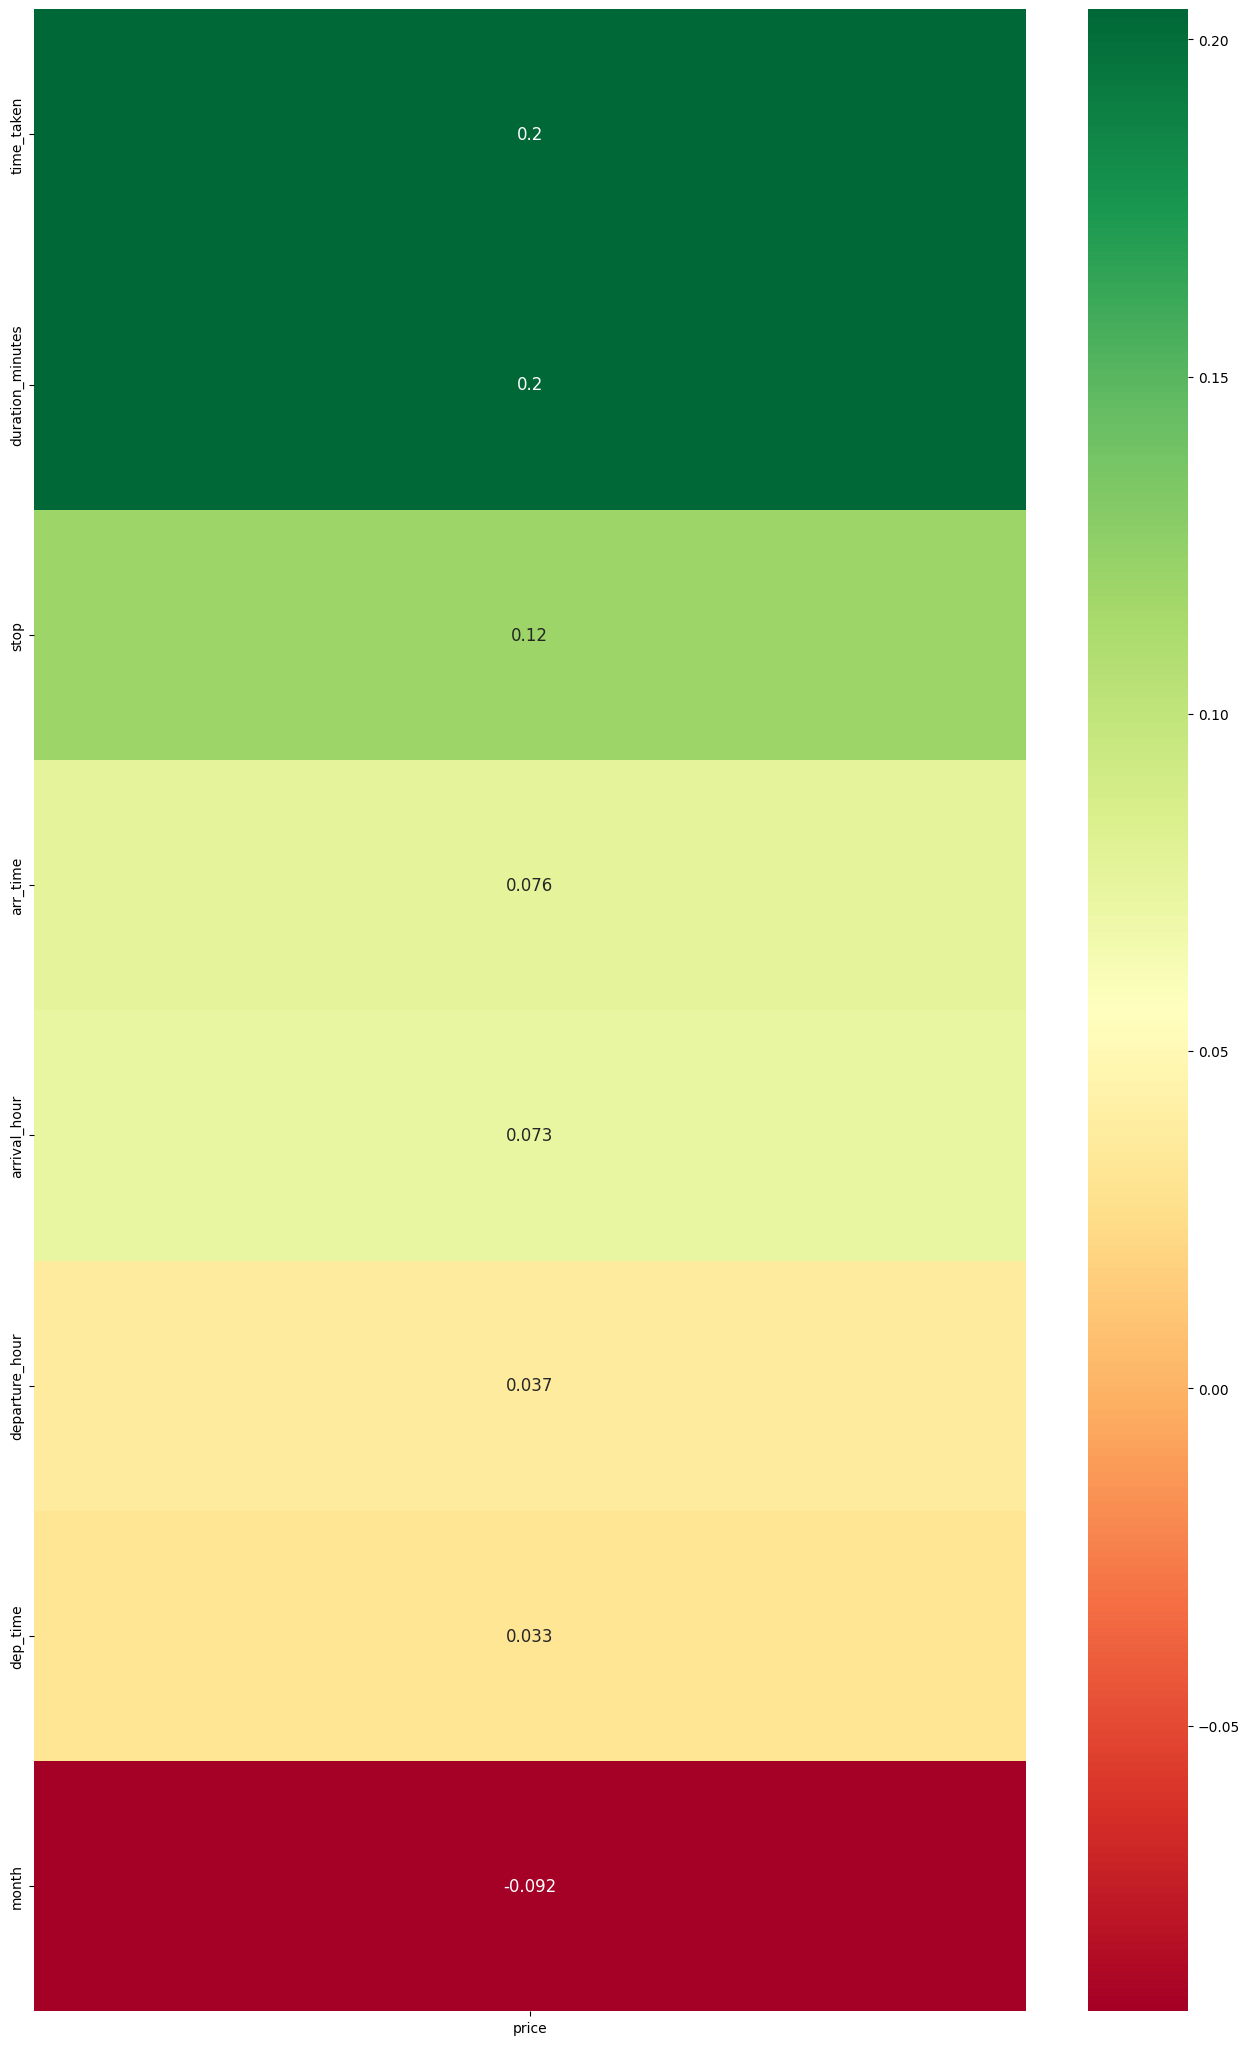

In [ ]:
# VARIABLE OBJETIVO 'price'

# Graficamos de manera descendente desde la correlación mas alta hasta la mas baja.
correlacion = Data_Set.select_dtypes(include = ['float64','int', 'uint8']).corr(method = 'pearson')

plt.rcParams.update({'font.size': 10})
plt.figure(figsize=(16, 26))

sns.heatmap(correlacion.loc[:, ['price']].sort_values('price', ascending=False).iloc[1:], annot=True, annot_kws={'size':12}, cmap = 'RdYlGn')

# 6. Generamos una función que resumirá todo el procesamiento utilizado para tratar el dataset, este leerá el dataset original y entregará un dataset ya tratado, con las columnas transformadas y creadas.

In [ ]:
# Creamos función para entregar el dataset original con todos los procesamientos realizados.
# Con este ultimo paso podemos obtener un set de datos listo para el analisis final.

def data_procesada(data_inicial):

    data = data_inicial.copy()

    # Eliminamos variables que no son necesarias
    variables_drop = ['ch_code', 'num_code']
    data = data.drop(variables_drop, axis=1)


    # CREACIÓN DE VARIABLES

    # Transformamos variable 'dep_time' y 'arr_time'
    data['dep_time'] = data['dep_time'].apply(lambda x: x.hour * 60 + x.minute)
    data['arr_time'] = data['arr_time'].apply(lambda x: x.hour * 60 + x.minute)

    # Extraemos solo números y transformamos variable 'time_taken'
    time_extract = data['time_taken'].str.extract('(\d+)h (\d+)m', expand=True)
    data['time_taken'] = pd.to_numeric(time_extract[0], errors='coerce')*60 + pd.to_numeric(time_extract[1], errors='coerce')

    # Transformamos variable 'price'
    data['price'] = data['price'].apply(lambda x: x.replace(',', '') if isinstance(x, str) else x)
    data['price'] = pd.to_numeric(data['price'], errors='coerce')

    # Transformamos variable 'stop'
    data['stop'] = data['stop'].str.replace('non-stop', '0stop')
    data['stop'] = data['stop'].str.extract('(\d+)', expand = True).astype('float')

    # Eliminamos datos faltantes.
    data = data.dropna(axis = 0)

    # CODIFICACIÓN DE VARIABLES

    # Duración del vuelo en minutos
    data['duration_minutes'] = data['time_taken'].astype(int)

    # Día de la semana y mes del viaje
    data['day_of_week'] = data['date'].dt.day_name()
    data['month'] = data['date'].dt.month

    # Hora del día de salida/llegada
    data['departure_hour'] = data['dep_time'] // 100
    data['arrival_hour'] = data['arr_time'] // 100

    # Hora de salida y llegada como franjas horarias
    data['departure_time_of_day'] = pd.cut(data['departure_hour'], bins=[0, 6, 12, 18, 24], labels=['Late Night', 'Morning', 'Afternoon', 'Evening'])
    data['arrival_time_of_day'] = pd.cut(data['arrival_hour'], bins=[0, 6, 12, 18, 24], labels=['Late Night', 'Morning', 'Afternoon', 'Evening'])

    # Ruta del vuelo
    data['flight_route'] = data['from'] + ' to ' + data['to']

    # Indicador de vuelo directo o con escalas
    data['direct_flight'] = data['stop'].apply(lambda x: 'Direct' if x == 0 else 'With Stops')


    # TRANSFORMACIÓN DE VARIABLES

    # Lista de variables categóricas que deseas codificar
    variables_categoricas = ['airline', 'from', 'to', 'class_type', 'day_of_week', 'departure_time_of_day', 'arrival_time_of_day', 'flight_route', 'direct_flight']

    # Aplicar codificación one-hot a las variables categóricas
    data = pd.get_dummies(data, columns=variables_categoricas)### **6.1 Función de tratamiento de datos**

    # Preparamos el set de datos final
    data.dropna(inplace=True)
    data = data.reset_index(drop=True)

    return data

In [ ]:
# Aplicamos la función
data_final = data_procesada(data_inicial)
data_final.head()

,date,dep_time,time_taken,stop,arr_time,price,duration_minutes,month,departure_hour,arrival_hour,...,flight_route_Kolkata to Delhi,flight_route_Kolkata to Hyderabad,flight_route_Kolkata to Mumbai,flight_route_Mumbai to Bangalore,flight_route_Mumbai to Chennai,flight_route_Mumbai to Delhi,flight_route_Mumbai to Hyderabad,flight_route_Mumbai to Kolkata,direct_flight_Direct,direct_flight_With Stops
0,2022-02-11,1080,120.0,0.0,1200,25612,120,2,10,12,...,False,False,False,False,False,False,False,False,True,False
1,2022-02-11,1140,135.0,0.0,1275,25612,135,2,11,12,...,False,False,False,False,False,False,False,False,True,False
2,2022-02-11,1200,1485.0,1.0,1245,42220,1485,2,12,12,...,False,False,False,False,False,False,False,False,False,True
3,2022-02-11,1285,1590.0,1.0,1435,44450,1590,2,12,14,...,False,False,False,False,False,False,False,False,False,True
4,2022-02-11,1035,400.0,1.0,1435,46690,400,2,10,14,...,False,False,False,False,False,False,False,False,False,True


In [ ]:
data_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300257 entries, 0 to 300256
Data columns (total 79 columns):
 #   Column                               Non-Null Count   Dtype         
---  ------                               --------------   -----         
 0   date                                 300257 non-null  datetime64[ns]
 1   dep_time                             300257 non-null  int64         
 2   time_taken                           300257 non-null  float64       
 3   stop                                 300257 non-null  float64       
 4   arr_time                             300257 non-null  int64         
 5   price                                300257 non-null  int64         
 6   duration_minutes                     300257 non-null  int64         
 7   month                                300257 non-null  int32         
 8   departure_hour                       300257 non-null  int64         
 9   arrival_hour                         300257 non-null  int64         
 

# 7. Elección de modelos candidatos para resolver el problema. A partir de esto, genera un conjunto de entrenamiento y prueba, para luego entrenar los diferentes modelos.

In [ ]:
# Importamos librerías requeridas
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression

In [ ]:
# Calculamos matriz de correlación.
correlation_matrix = data_final.corr()
correlation_price = correlation_matrix['price'].sort_values(ascending=False).iloc[1:]

# Seleccionamos las características con una correlación absoluta mayor que el umbral definido.
threshold = 0.1
filter_correlation = correlation_price[abs(correlation_price) > threshold].index.tolist()
print(f'\033[1mCaracterísticas seleccionadas por Filtro de Correlación:\033[0m')
print(filter_correlation)

Características seleccionadas por Filtro de Correlación:
['class_type_business', 'airline_Vistara', 'time_taken', 'duration_minutes', 'direct_flight_With Stops', 'stop', 'airline_SpiceJet', 'airline_AirAsia', 'direct_flight_Direct', 'airline_GO FIRST', 'airline_Indigo', 'class_type_economy']


FORWARD SELECTION

In [ ]:
# Dividimos los datos en conjuntos de entrenamiento y prueba
X = data_final.drop(['price', 'date'], axis=1)
target = data_final.loc[:, ['price']]

In [ ]:
# Crear un modelo base (por ejemplo, Regresión Lineal)
base_model = LinearRegression()

In [ ]:
# Utilizar Forward Selection para seleccionar características
sfs = SequentialFeatureSelector(base_model, n_features_to_select=12, direction='forward', scoring='accuracy', cv=5)
sfs.fit(X, target)
selected_features = X.columns[sfs.support_]
print(f'\033[1mCaracterísticas seleccionadas por Forward Selection:\033[0m')
print(selected_features)

Características seleccionadas por Forward Selection:
Index(['dep_time', 'time_taken', 'stop', 'arr_time', 'duration_minutes',
       'month', 'departure_hour', 'arrival_hour', 'airline_Air India',
       'airline_AirAsia', 'airline_GO FIRST', 'airline_Indigo'],
      dtype='object')


In [64]:
# Importamos librerías requeridas
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [65]:
# Dividimos los datos en conjuntos de entrenamiento y prueba.
X = data_final[filter_correlation].copy()
y = data_final['price'].copy()

# Normalización de datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [66]:
# Generamos las muestras de entrenamiento y validación 80/20
X_train, X_test, y_train, y_test = train_test_split(X_scaled,
                                                    y,
                                                    test_size=0.20,
                                                    random_state=42)

# 8. Elige una grilla de hiperparametros y luego optimízalos, buscando la mejor combinación para cada grilla. Guardar los modelos entrenados.

In [78]:
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.linear_model import ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

def find_best_model(X, y):
    # Definir los hiperparámetros a ajustar para cada algoritmo
    lasso_params = {'alpha': [0.001, 0.01, 0.1, 1, 10]}
    ridge_params = {'alpha': [0.001, 0.01, 0.1, 1, 10]}
    elastic_params = {'alpha': [0.001, 0.01, 0.1, 1, 10],
                      'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]}
    tree_params = {'max_depth': [None, 10, 20, 30],
                   'min_samples_split': [2, 5, 10],
                   'min_samples_leaf': [1, 2, 4]}
                    # Definir los modelos
    lasso = Lasso()
    ridge = Ridge()
    elastic = ElasticNet()
    tree = DecisionTreeRegressor()

    # Realizar la búsqueda de hiperparámetros utilizando validación cruzada
    models = [lasso, ridge, elastic, tree]
    params = [lasso_params, ridge_params, elastic_params, tree_params]
    best_model = None
    best_params = None
    best_score = float('-inf')

    models_save = []

    for model, param_grid in zip(models, params):
        grid_search = GridSearchCV(model, param_grid, cv=5, scoring='neg_mean_squared_error')
        grid_search.fit(X, y)

        if grid_search.best_score_ > best_score:
            best_score = grid_search.best_score_
            best_model = model
            best_params = grid_search.best_params_
        print("Best Model: ", grid_search.best_estimator_)
        print("Best params: ", grid_search.best_params_)
        print("Ajuste: ", -grid_search.best_score_)
        print('-'*100)
        models_save.append(grid_search.best_estimator_)

    return best_model, best_params, models_save

    # Ejemplo de uso con datos X_train y y_train
best_model, best_params, models = find_best_model(X_train, y_train)
print("Mejor modelo:", best_model)
print("Mejores hiperparámetros:", best_params)

Best Model:  Lasso(alpha=0.01)
Best params:  {'alpha': 0.01}
Ajuste:  50618392.24448021
----------------------------------------------------------------------------------------------------
Best Model:  Ridge(alpha=10)
Best params:  {'alpha': 10}
Ajuste:  50618391.872509606
----------------------------------------------------------------------------------------------------
Best Model:  ElasticNet(alpha=0.001, l1_ratio=0.9)
Best params:  {'alpha': 0.001, 'l1_ratio': 0.9}
Ajuste:  50618392.30555161
----------------------------------------------------------------------------------------------------
Best Model:  DecisionTreeRegressor(min_samples_split=10)
Best params:  {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10}
Ajuste:  29385182.388219077
----------------------------------------------------------------------------------------------------
Mejor modelo: DecisionTreeRegressor()
Mejores hiperparámetros: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10}

Error Cuadrático Medio (MSE): 42731631.59001833


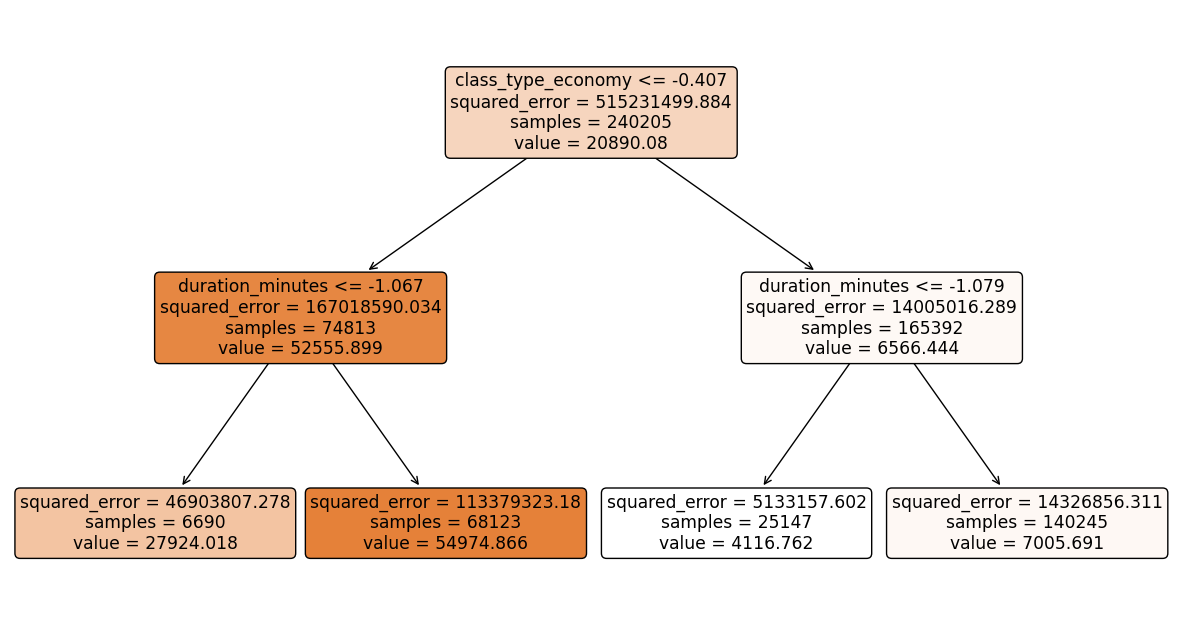

In [79]:
from sklearn.metrics import mean_squared_error
from sklearn.tree import plot_tree

# Crear y entrenar el modelo de árbol de regresión. Fijamos la profundidad en 2
reg_tree = DecisionTreeRegressor(max_depth=2, random_state=42)
reg_tree.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred = reg_tree.predict(X_test)

# Calcular el error cuadrático medio (MSE)
mse = mean_squared_error(y_test, y_pred)
print("Error Cuadrático Medio (MSE):", mse)

# Graficar el árbol de regresión
plt.figure(figsize=(15, 8))
plot_tree(reg_tree, feature_names=X.columns, filled=True, rounded=True)
plt.show()

# 9. Define al menos 3 métricas para evaluar los modelos entrenados y genera gráficos de comparación. Elige un baseline para ver qué tan buena es tu opción respecto a ese baseline y concluye.

lasso
lasso R2:  0.8996317700813683
lasso RMSE:  7186.7896287976655
lasso MAPE:  0.4985494365003434
----------------------------------------------------------------------------------------------------
ridge
ridge R2:  0.8996317945678844
ridge RMSE:  7186.788752128569
ridge MAPE:  0.4985509097957814
----------------------------------------------------------------------------------------------------
elastic_net
elastic_net R2:  0.899631706210962
elastic_net RMSE:  7186.79191549287
elastic_net MAPE:  0.4985403423006941
----------------------------------------------------------------------------------------------------
regresion_tree
regresion_tree R2:  0.9428194039345175
regresion_tree RMSE:  5424.517804623392
regresion_tree MAPE:  0.3081394641428976
----------------------------------------------------------------------------------------------------


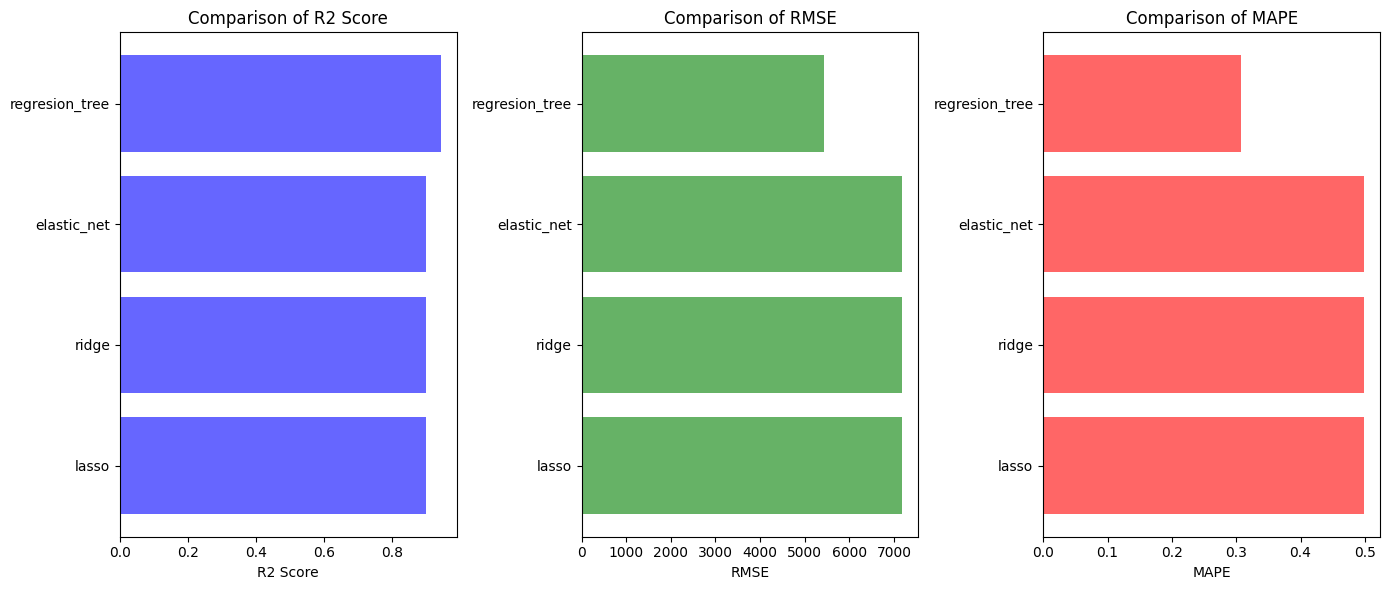

In [92]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.linear_model import Lasso, LassoCV
from sklearn.linear_model import ElasticNet, ElasticNetCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error
import pickle
import warnings

warnings.filterwarnings('ignore')

def evaluation_model(model, X_test, y_test, name):
    y_predict = model.predict(X_test)
    r2 = r2_score(y_test, y_predict)
    rmse = mean_squared_error(y_test, y_predict, squared=False)  # Using squared=False to get RMSE directly
    mape = mean_absolute_percentage_error(y_test, y_predict)
    print(f'{name} R2: ', r2)
    print(f'{name} RMSE: ', rmse)
    print(f'{name} MAPE: ', mape)
    with open(f'./{name}_housedata.pkl', 'wb') as f:
        pickle.dump(model, f)
    return r2, rmse, mape

names = ['lasso', 'ridge', 'elastic_net', 'regresion_tree']

# Lista para almacenar los resultados
results = {}

# Evaluar y guardar los resultados para cada modelo
for n, m in zip(names, models):
    print(n)
    r2, rmse, mape = evaluation_model(m, X_test, y_test, n)
    results[n] = {'R2': r2, 'RMSE': rmse, 'MAPE': mape}
    print('-'*100)

# Extraer los resultados para la creación de gráficos
model_names = list(results.keys())
r2_scores = [results[name]['R2'] for name in model_names]
rmse_values = [results[name]['RMSE'] for name in model_names]
mape_values = [results[name]['MAPE'] for name in model_names]

# Crear el gráfico de barras para R2 Score
plt.figure(figsize=(14, 6))

# Gráfico para R2 Score
plt.subplot(1, 3, 1)
plt.barh(model_names, r2_scores, color='blue', alpha=0.6)
plt.xlabel('R2 Score')
plt.title('Comparison of R2 Score')

# Gráfico para RMSE
plt.subplot(1, 3, 2)
plt.barh(model_names, rmse_values, color='green', alpha=0.6)
plt.xlabel('RMSE')
plt.title('Comparison of RMSE')

# Gráfico para MAPE
plt.subplot(1, 3, 3)
plt.barh(model_names, mape_values, color='red', alpha=0.6)
plt.xlabel('MAPE')
plt.title('Comparison of MAPE')

# Ajustar los subgráficos
plt.tight_layout()
plt.show()


El análisis de los datos de vuelos nos ha permitido obtener varias conclusiones clave sobre los factores que influyen en el precio de los boletos y las características de los vuelos. A continuación, se resumen los hallazgos más relevantes:

*   Distribución de las Fechas de los Vuelos
*   Aerolineas que predominan
*   Distribución de Orígenes y Destinos
*   Tiempos de vuelo
*   Numero de escalas
*   Precio de los pasajes aereos
*   Determinar horarios de salida y llegada

Como proximos pasos se puede realizar un monitoreo y actualización del modelo realizando un Monitoreo Continuo, Implementar un sistema de monitoreo para evaluar continuamente el rendimiento del modelo con nuevos datos y detectar cualquier deterioro en su precisión, así como también una actualización Periódica,para establecer un proceso para actualizar el modelo periódicamente con datos nuevos y ajustar los hiperparámetros según sea necesario.

Una implementación en producción para desarrollar una infraestructura para desplegar el modelo en un entorno de producción, asegurando que las predicciones sean accesibles para los usuarios finales o sistemas automatizados.
Documentación y Educación el proceso del modelo y sus resultados, y educar a los stakeholders sobre cómo interpretar y utilizar las predicciones del modelo.











